# **SONYC-UST: Data Validation and Preparation Pipeline**

This notebook defines a structured pipeline to validate and prepare the SONYC Urban Sound Tagging (SONYC-UST) dataset for machine learning. Using a custom `soundata`-based wrapper, it ensures that metadata, annotations, and audio files are aligned and accessible.

By the end of this notebook, you will have:

- Verified dataset structure and metadata consistency  
- Confirmed availability and integrity of all audio files  
- Visualized label distributions and temporal coverage  
- Inspected spectrogram generation for training inputs  
- Computed summary metrics to assess dataset quality  

## Step 1: **Environment Setup and Dataset Initialization**
---

This step sets up the runtime environment by importing essential libraries and initializing the SONYC-UST dataset wrapper.

All core dependencies for data processing, visualization, and modeling are loaded. The custom `SonycUST` wrapper is then instantiated to provide structured access to the dataset—including annotation loading, audio path resolution, and schema validation.

This prepares the environment for all subsequent preprocessing, analysis, and training stages.

In [ ]:
""" LIBRARY AND PROJECT IMPORTS """

# === Optional: Install missing packages (uncomment if needed) ===
# !pip install numpy pandas matplotlib seaborn librosa soundfile tqdm scikit-learn tensorflow tensorflow-hub soundata

# --- Core Libraries ---
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

# --- Audio Processing ---
import librosa
import soundfile as sf

# Temporary fix for deprecated np.complex in newer NumPy versions
np.complex = complex  

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix

# --- Project-Specific Imports ---
from wrapper import SonycUST                     # Custom dataset wrapper for SONYC-UST
from utils import load_data, process_audio, plot_spectrogram  # Utility functions
from classification import (
    cnn_model, tcn_model, train_model, compile_model, 
    build_cnn_model, compile_augmented_model, create_augmented_dataset,
    data_set
)

In [ ]:
""" INITIALIZE DATASET WRAPPER """

# --- Define dataset root directory ---
data_home = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/sonyc-ust'

# --- Initialize SONYC-UST dataset wrapper ---
dataset = SonycUST(data_home=data_home)  # Creates an instance of the custom Soundata wrapper

## Step 2: **Dataset Validation and Annotation Inspection**

To ensure the reliability of downstream modeling, we first validate the dataset structure and annotation integrity. This step confirms that all required audio files and metadata are correctly organized and accessible.

Using the `SonycUST` wrapper, we:
- Check that the dataset directory includes all required folders and the annotation file.
- Load and inspect the annotation table to confirm schema consistency and field availability.
- Validate that entries in the metadata correctly resolve to existing `.wav` files.

This ensures that the dataset is fully intact, well-structured, and ready for supervised training.

In [ ]:
"""Dataset Validation and Annotation Inspection"""

# Validate the dataset structure (checks for required directories and files)
print("Validating dataset structure...")
dataset.validate_structure()

# Load annotations and print summary stats
annotations = dataset.load_annotations()
print("\nAnnotations summary:")
print(f"Total annotations: {len(annotations)}")

# Print out column names to inspect the structure of the annotations dataframe
print("\nColumns in annotations file:")
print(annotations.columns.tolist())

# Extract a sample filename from the annotations
sample_file = annotations['audio_filename'].iloc[0]

# Get the corresponding full file path using the dataset wrapper
audio_path = dataset.get_audio_path(sample_file)

# Confirm that the audio file exists and display its path
print(f"\nSample audio file path exists: {audio_path is not None}")
if audio_path:
    print(f"Located in: {audio_path.parent}")

# Step 3: Dataset Overview
---

This step summarizes the structure and metadata of the SONYC-UST dataset after successful validation.

### Directory Structure
- 38 audio folders (19 `.tar.gz` + 19 extracted).
- Central `annotations.csv` containing all labels.
- All audio files are verified as accessible via the custom wrapper.

### Metadata Summary
- **62,022 labeled entries** with rich annotations per clip.
- Includes spatial (sensor, borough, GPS), temporal (hour, day, week, year), and annotator metadata.

### Labeling Schema
- **Split fields**: Identifies train/validate/test partitions.
- **Binary labels** for both presence and proximity across multiple classes.
- Supports coarse and fine-grained classification for flexible modeling.

This structure supports spatiotemporal and multi-label analysis of urban acoustic environments.

In [ ]:
""" DATASET DEFINITIONS """

def analyze_dataset(annotations):
    """
    Analyze general dataset characteristics, including:
    - Split distribution
    - Coarse label frequency
    - Temporal (hourly) distribution

    Parameters:
    ----------
    annotations : pd.DataFrame
        DataFrame containing metadata and presence labels for each audio sample.
    """
    print("Dataset Analysis:")
    
    # --- Dataset split counts ---
    print("\nSplit Distribution:")
    print(annotations['split'].value_counts())
    
    # --- Coarse label presence counts ---
    coarse_labels = [
        col for col in annotations.columns 
        if col.endswith('_presence') and len(col.split('_')) == 2
    ]
    
    print("\nCoarse Label Distribution:")
    total = len(annotations)
    for label in coarse_labels:
        count = annotations[label].sum()
        print(f"{label}: {count} ({(count / total) * 100:.2f}%)")
    
    # --- Hour-of-day distribution ---
    print("\nTemporal Distribution:")
    print("Hours distribution:")
    print(annotations['hour'].value_counts().sort_index())


def visualize_distributions(annotations):
    """
    Visualize:
    - Dataset split proportions
    - Recording distribution by hour of day

    Parameters:
    ----------
    annotations : pd.DataFrame
        DataFrame with dataset metadata and labels.
    """
    plt.figure(figsize=(15, 10))  # Layout for 2 subplots

    # --- Subplot 1: Split distribution ---
    plt.subplot(2, 1, 1)
    splits = annotations['split'].value_counts()
    plt.bar(splits.index, splits.values)
    plt.title('Dataset Split Distribution')
    plt.ylabel('Number of Samples')

    # --- Subplot 2: Hourly activity ---
    plt.subplot(2, 1, 2)
    hours = annotations['hour'].value_counts().sort_index()
    plt.plot(hours.index, hours.values, marker='o')
    plt.title('Hourly Distribution of Recordings')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Recordings')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
""" GROUPED AND TITLED PRESENCE COLUMNS """

from collections import defaultdict

# Correct group titles
group_titles = {
    '1': "Engine Sounds",
    '2': "Machinery Impact",
    '3': "Non-Machinery Impact",
    '4': "Powered Saw",
    '5': "Alert Signal",
    '6': "Music",
    '7': "Human Voice",
    '8': "Dog Sounds"
}

# Extract all presence-related columns from annotations
presence_cols = [col for col in annotations.columns if col.endswith('_presence')]

# Create grouping dictionary
grouped_presence = defaultdict(list)

for col in presence_cols:
    # Extract leading group number
    if '-' in col:
        leading_number = col.split('-')[0]  # Fine-grained label
    else:
        leading_number = col.split('_')[0]  # Coarse label
    
    leading_number = leading_number[0]  # Only keep major group number (1-8)

    grouped_presence[leading_number].append(col)

# Define standard line width for clean formatting
LINE_WIDTH = 50  # Adjustable

# Print grouped results
print("Available presence columns (grouped by category):\n")
for group, cols in sorted(grouped_presence.items()):
    title = group_titles.get(group, "Unknown Category")
    
    line = "-" * LINE_WIDTH  # Automatically create a long line
    print(line)
    print(f"Group {group}: {title}".center(LINE_WIDTH))
    print(line)
    
    for col in cols:
        print(f" {col}")
    print()  # Blank line between groups

# Step 4: Dataset Preparation and Weighting
---

This step prepares training data by generating mel spectrograms and computing weights to address label imbalance in the SONYC-UST dataset.

### Label Structure  
Each clip is annotated with 8 coarse-grained binary presence labels representing key urban sound types. These are encoded as multi-hot vectors:

$$
\mathbf{y} \in \{0,1\}^8
$$

### Class Weighting  
To prevent bias toward frequent classes, class weights are computed as:

$$
w_i = \frac{N_{\text{total}}}{N_i}
$$

where $N_i$ is the number of positive samples for class $i$. The weights are normalized to ensure:

$$
\text{mean}(w_i) = 1
$$

### Weighted Loss Function  
The model uses a class-weighted binary cross-entropy loss:

$$
\mathcal{L} = \frac{1}{C} \sum_{i=1}^C w_i \cdot \text{BCE}(y_i, \hat{y}_i)
$$

where $C$ is the number of classes, $y_i$ is the ground truth, and $\hat{y}_i$ is the predicted probability.

### Spectrogram Dataset Construction  
Each `.wav` file is converted to a normalized mel spectrogram of shape $(128, 128, 1)$.  
These spectrograms are paired with label vectors and returned as `tf.data.Dataset` objects.

### Train/Validation Splits  
- **Training Set**: First 10,000 clips from the `train` split  
- **Validation Set**: First 10,000 clips from the `validate` split  

All processed examples are verified and visualized to ensure spectrogram-label alignment.

In [ ]:
""" DATASET PREPARATION AND WEIGHTING """

from tqdm import tqdm
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the 8 coarse-grained label columns
COARSE_PRESENCE_COLS = [
    '1_engine_presence',
    '2_machinery-impact_presence',
    '3_non-machinery-impact_presence',
    '4_powered-saw_presence',
    '5_alert-signal_presence',
    '6_music_presence',
    '7_human-voice_presence',
    '8_dog_presence'
]

# --- Compute Class Weights to Handle Imbalance ---
def compute_class_weights(annotations, label_columns):
    """
    Compute inverse-frequency class weights based on label prevalence.
    """
    label_sums = annotations[label_columns].sum().values
    total = len(annotations)
    weights = total / (label_sums + 1e-6)  # Avoid division by zero
    weights /= np.mean(weights)  # Normalize so mean = 1
    return weights.tolist()

# --- Define Weighted Loss Function ---
def get_weighted_binary_crossentropy(class_weights):
    """
    Create a weighted binary cross-entropy loss function.
    """
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weighted_bce = bce * class_weights_tensor
        return tf.reduce_mean(weighted_bce, axis=-1)

    return loss_fn

# --- Compute class weights based on dataset ---
class_weights = compute_class_weights(annotations, COARSE_PRESENCE_COLS)

def prepare_data(annotations, dataset, target_shape=(128, 128), max_samples=10000):
    """
    Prepare TensorFlow datasets for training and validation.
    """
    # Split annotations into train and validate subsets
    train_df = annotations[annotations['split'] == 'train'].head(max_samples)
    val_df = annotations[annotations['split'] == 'validate'].head(max_samples)

    print(f"Using {len(train_df)} training samples and {len(val_df)} validation samples")

    def create_tf_dataset(df, is_training=True):
        """
        Build TensorFlow dataset from file paths and multi-hot labels.
        """
        audio_files, labels = [], []

        # --- Step 1: Verify all audio file paths and labels ---
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking audio paths"):
            audio_path = dataset.get_audio_path(row['audio_filename'])
            if audio_path is None:
                print(f"File not found via get_audio_path: {row['audio_filename']}")
            elif not os.path.exists(audio_path):
                print(f"Path returned but file missing: {audio_path}")
            else:
                label = [row[col] for col in COARSE_PRESENCE_COLS]
                audio_files.append(str(audio_path))
                labels.append(label)

        print(f"Found {len(audio_files)} valid audio files")

        # --- Step 2: Convert to NumPy arrays ---
        audio_files = np.array(audio_files)
        labels = np.array(labels, dtype=np.float32)

        # --- Step 3: Process spectrograms from audio files ---
        processed_specs = []
        processed_labels = []

        for audio_file, label in tqdm(zip(audio_files, labels), total=len(audio_files), desc="Processing spectrograms"):
            try:
                spec = process_audio(audio_file, target_shape)
                if spec is not None and spec.shape == (target_shape[0], target_shape[1], 1):
                    processed_specs.append(spec)
                    processed_labels.append(label)
            except Exception as e:
                print(f"Error processing {audio_file}: {e}")

        # --- Step 4: Create tf.data.Dataset ---
        if processed_specs:
            processed_specs = np.stack(processed_specs)
            processed_labels = np.stack(processed_labels)
            ds = tf.data.Dataset.from_tensor_slices((processed_specs, processed_labels))
        else:
            ds = tf.data.Dataset.from_tensor_slices((
                np.zeros((0, target_shape[0], target_shape[1], 1), dtype=np.float32),
                np.zeros((0, len(COARSE_PRESENCE_COLS)), dtype=np.float32)
            ))

        # --- Step 5: Batch, Prefetch, Shuffle ---
        ds = ds.batch(32)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        
        if is_training:
            ds = ds.shuffle(1000)

        return ds

    # --- Create training and validation datasets ---
    train_data = create_tf_dataset(train_df, is_training=True)
    val_data = create_tf_dataset(val_df, is_training=False)

    return train_data, val_data

print("Creating datasets with a subset for initial testing...")
train_data, val_data = prepare_data(annotations, dataset, max_samples=10000)

# --- Check sample shapes ---
print("\nDataset shapes:")
for x, y in train_data.take(1):
    print(f"Training batch - X: {x.shape}, y: {y.shape}\n")

for x, y in val_data.take(1):
    print(f"Validation batch - X: {x.shape}, y: {y.shape}\n")

# --- Visualize example sample ---
for x, y in train_data.take(1):
    if x.shape[0] > 0:
        plt.figure(figsize=(10, 4))

        # Plot Spectrogram
        plt.subplot(1, 2, 1)
        plt.imshow(x[0, :, :, 0])
        plt.colorbar()
        plt.title('Sample Mel Spectrogram')

        # Plot Label Distribution
        plt.subplot(1, 2, 2)
        plt.bar(range(len(COARSE_PRESENCE_COLS)), y[0])
        plt.xticks(range(len(COARSE_PRESENCE_COLS)), [c.split('_')[0] for c in COARSE_PRESENCE_COLS], rotation=45)
        plt.title('Sample Multi-Label Encoding')

        plt.tight_layout()
        plt.show()

# Step 5: Model Architecture and Training
---

This step defines, compiles, and trains two deep learning models on Mel spectrogram inputs to perform multi-label urban sound classification.

### CNN (Convolutional Neural Network)
- Operates on 2D Mel spectrograms: shape $(128, 128, 1)$
- Extracts local time-frequency patterns
- Architecture: 3 convolutional blocks → Global Average Pooling → Dense output

### TCN (Temporal Convolutional Network)
- Treats Mel features as temporal sequences: shape $(128, 128)$
- Uses stacked dilated 1D convolutions to model temporal dependencies
- Architecture: Dilated Conv1D stack → Global Average Pooling → Dense output

### Training Configuration
Both models are trained with:
- **Loss**: Binary crossentropy with label smoothing
- **Optimizer**: Adam
- **Metrics**: Binary Accuracy, AUC
- **Callbacks**: Early stopping, learning rate scheduling, model checkpointing

Training histories are visualized to compare convergence and performance between the CNN and TCN architectures.

In [ ]:
""" MODEL IMPORTS AND TRAINING SETUP """

# Import model architectures and training functions
from classification import cnn_model, tcn_model, train_model, compile_model

# Define input shapes for the models
cnn_input_shape = (128, 128, 1)  # CNN expects spectrogram input: height x width x channels
tcn_input_shape = (128, 128)     # TCN expects sequential input: time steps x features

# Determine number of output classes from dataset taxonomy
num_classes = len(dataset.label_taxonomy)

# Build and compile the CNN model
cnn = cnn_model(cnn_input_shape, num_classes)
cnn = compile_model(cnn)

# Build and compile the TCN model
tcn = tcn_model(tcn_input_shape, num_classes)
tcn = compile_model(tcn)

cnn_history = train_model(cnn, train_data, val_data)    # Train the CNN model
tcn_history = train_model(tcn, train_data, val_data)    # Train the TCN model

In [ ]:
""" PLOT TRAINING METRICS FOR CNN AND TCN """

# Set overall figure size
plt.figure(figsize=(12, 5))

# Plot Loss curves
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='CNN Train')
plt.plot(cnn_history.history['val_loss'], label='CNN Val')
plt.plot(tcn_history.history['loss'], label='TCN Train')
plt.plot(tcn_history.history['val_loss'], label='TCN Val')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Binary Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['binary_accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_binary_accuracy'], label='CNN Val')
plt.plot(tcn_history.history['binary_accuracy'], label='TCN Train')
plt.plot(tcn_history.history['val_binary_accuracy'], label='TCN Val')
plt.title('Binary Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.legend()

# Adjust subplot spacing and show plots
plt.tight_layout()
plt.show()

### Updated Training Analysis

| Aspect                   | Status / Results                                      |
|--------------------------|-------------------------------------------------------|
| **CNN Performance**      | ~70% validation binary accuracy; smooth loss decline  |
| **TCN Performance**      | ~60% accuracy; consistent convergence                 |
| **Generalization**       | Models now generalize beyond training set             |
| **Sample Size**          | Expanded from 5 to over 1000 annotated examples       |
| **Class Weighting**      | Custom loss compensates for label imbalance           |
| **Loss Behavior**        | Stable across training; no divergence observed        |

---

### Data Summary

- **Total Samples**: 62,022 annotated clips  
- **Label Space**: 8 coarse sound classes (multi-label)  
- **Metadata**: Time, location, sensor, annotator  
- **Temporal Patterns**: Peak activity during rush hours  
- **Acoustic Diversity**: High environmental variability across boroughs  



# Step 6: **Model Training with Class-Weighted Augmentation**
---

This step initializes and trains a CNN model on Mel spectrogram inputs using a class-weighted augmentation strategy to address label imbalance.

### Training Configuration
- **Data Splits**: 10,000 clips each from `train` and `validate`
- **Preprocessing**:  
  - Audio files are converted to `(128 × 128)` Mel spectrograms  
  - Labels are multi-hot encoded across 8 coarse sound categories  
  - Data is batched and prefetched via `tf.data.Dataset`

### Class Imbalance Visualization
A bar chart is generated to show class frequency distribution across the 8 presence labels, revealing the extent of imbalance across categories.

### Model Compilation
A CNN is compiled with:
- **Loss**: Weighted binary cross-entropy with label smoothing
- **Metrics**: `BinaryAccuracy` and `AUC`
- **Optimizer**: Adam

### Training Strategy
Class weights are injected into the data pipeline using a custom augmentation wrapper. Training includes:
- Early stopping based on `val_loss`
- Learning rate reduction on plateau
- Checkpointing the best model weights

This setup ensures regularization against overfitting while emphasizing rare classes during optimization.

In [ ]:
""" PLOT CLASS IMBALANCE """

import matplotlib.pyplot as plt

def plot_class_imbalance(annotations_df, label_columns):
    """
    Plot class imbalance for multi-label classification datasets.

    Parameters
    ----------
    annotations_df : pd.DataFrame
        DataFrame containing binary presence columns for each class.
    label_columns : list of str
        List of column names corresponding to presence labels.
    """
    # Convert presence columns to numeric (handle any unexpected values safely)
    presence_clean = annotations_df[label_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

    # Clip values to [0, 1] to ensure binary validity
    presence_clipped = presence_clean.clip(lower=0, upper=1)

    # Compute total positive samples per class
    class_counts = presence_clipped.sum().astype(int)

    # Create bar plot
    plt.figure(figsize=(16, 6))
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title("Class Imbalance in Dataset")
    plt.ylabel("Number of Positive Samples")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Define the coarse-grained presence columns ---
COARSE_PRESENCE_COLS = [
    '1_engine_presence',
    '2_machinery-impact_presence',
    '3_non-machinery-impact_presence',
    '4_powered-saw_presence',
    '5_alert-signal_presence',
    '6_music_presence',
    '7_human-voice_presence',
    '8_dog_presence'
]

# --- Plot the class imbalance ---
plot_class_imbalance(annotations, COARSE_PRESENCE_COLS)

In [ ]:
""" MODEL TRAINING WITH CLASS-WEIGHTED AUGMENTATION """

# Create training and validation splits
train_annotations_df = annotations[annotations['split'] == 'train'].head(10000)
val_annotations_df = annotations[annotations['split'] == 'validate'].head(10000)

# Retrieve corresponding audio file paths
train_file_paths = [dataset.get_audio_path(f) for f in train_annotations_df['audio_filename']]
val_file_paths = [dataset.get_audio_path(f) for f in val_annotations_df['audio_filename']]

# Create TensorFlow datasets from file paths and annotations
train_dataset = data_set(
    file_paths=train_file_paths,
    batch_size=64,
    target_shape=(128, 128),
    annotations_df=train_annotations_df,
    shuffle=True
)

val_dataset = data_set(
    file_paths=val_file_paths,
    batch_size=64,
    target_shape=(128, 128),
    annotations_df=val_annotations_df,
    shuffle=False
)

# Build and compile the CNN model
model = c.build_cnn_model(input_shape=(128, 128, 1), num_classes=8)
model = c.compile_augmented_model(model)

# Apply class-weighted data augmentation to the training dataset
train_dataset = c.create_augmented_dataset(train_dataset, class_weights)

# Train the model with early stopping, learning rate reduction, and checkpointing
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            save_best_only=True,
            monitor='val_loss'
        )
    ]
)

In [ ]:
""" AUGMENTED MODEL TRAINING & HISTORY VISUALIZATION """

import matplotlib.pyplot as plt

# Initialize a figure for plotting training metrics
plt.figure(figsize=(12, 5))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Training and Validation Binary Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['binary_accuracy'], label='Training Binary Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Binary Accuracy')
plt.title('Binary Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Step 7: **TCN Training on YAMNet Embeddings**
---

This section leverages **YAMNet**, a pre-trained audio embedding model from TensorFlow Hub, to transform raw waveforms into high-level feature representations before training a downstream model.

### YAMNet Embedding Pipeline
- Each audio file is resampled to 16 kHz and passed through YAMNet.
- YAMNet outputs a 1024-dimensional embedding vector per frame.
- These frame-wise embeddings are padded into batches of shape `(batch_size, time, 1024)`.

### Dataset Construction
- A `tf.data.Dataset` is created from `(audio_path, label)` pairs.
- Embeddings are computed using `tf.py_function` to retain dynamic shape support.
- Batches are padded and prefetched for training efficiency.

### TCN Classifier
- A **Temporal Convolutional Network (TCN)** is trained on the sequence of YAMNet embeddings.
- Input shape: `(None, 1024)`
- Output: 8 binary presence predictions (multi-label)

### Training Configuration
- Loss: Binary crossentropy
- Metrics: `BinaryAccuracy`
- Optimizer: Adam
- Callbacks: Early stopping, model checkpointing

This approach shifts the burden of low-level feature learning to YAMNet, allowing the TCN to focus on **temporal structure** in the high-level embedding space.

In [ ]:
""" YAMNet Embedding Mapping Function
This block defines the mapping function used to convert raw audio files
into feature embeddings using the pretrained YAMNet model. It wraps the 
inference logic inside a `tf.py_function` to enable compatibility within
TensorFlow data pipelines.

Output embeddings have shape (T, 1024), where T is the number of frames
and 1024 is the dimensionality of each feature vector.
"""

# === YAMNet Embedding Pipeline ===
import os
import numpy as np
import librosa
import tensorflow as tf
import tensorflow_hub as hub

# --- Load Pretrained YAMNet Model ---
yamnet = hub.load('https://tfhub.dev/google/yamnet/1')

# --- Define Mapping Function for tf.data ---
def map_with_yamnet(file_path, label):
    """
    Map function that extracts YAMNet embeddings from an audio file.
    
    Parameters:
        file_path (tf.Tensor): Tensor containing the file path string
        label (tf.Tensor): Corresponding multi-label vector
        
    Returns:
        (tf.Tensor, tf.Tensor): (YAMNet embedding, label)
    """
    def load_and_embed(path):
        path = path.numpy().decode("utf-8")
        audio, _ = librosa.load(path, sr=16000)
        _, embeddings, _ = yamnet(audio)
        return embeddings.numpy().astype(np.float32)

    # Wrap in tf.py_function for compatibility inside tf.data pipeline
    embeddings = tf.py_function(func=load_and_embed, inp=[file_path], Tout=tf.float32)
    embeddings.set_shape([None, 1024])  # Output: variable-length sequence, 1024-dim features
    
    return embeddings, label

In [ ]:
# Example audio path and label lists
audio_paths = [str(p) for p in train_file_paths]  # list of file paths
labels = [train_annotations_df.loc[train_annotations_df['audio_filename'] == os.path.basename(p), COARSE_PRESENCE_COLS].values[0] for p in audio_paths]

# Convert to tensors
audio_paths_tensor = tf.constant(audio_paths)
labels_tensor = tf.constant(labels, dtype=tf.float32)

# Build dataset
yamnet_dataset = tf.data.Dataset.from_tensor_slices((audio_paths_tensor, labels_tensor))
yamnet_dataset = yamnet_dataset.map(map_with_yamnet, num_parallel_calls=tf.data.AUTOTUNE)
yamnet_dataset = yamnet_dataset.padded_batch(32, padded_shapes=([None, 1024], [8]))
yamnet_dataset = yamnet_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
input_shape = (None, 1024)  # Variable-length sequence, 1024-dim features

# Assume tcn_model is already defined
model = tcn_model(input_shape, num_classes=8)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['binary_accuracy'])

# Train model
history = model.fit(
    yamnet_dataset,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('yamnet_model.keras', save_best_only=True)
    ]
)

In [ ]:
import matplotlib.pyplot as plt

def plot_training_metrics(history):
    """
    Plot training loss and accuracy from model.fit() history object.
    
    Parameters
    ----------
    history : keras.callbacks.History
        Training history returned by model.fit().
    """
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
    if 'val_binary_accuracy' in history.history:
        plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
    plt.title('Binary Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_metrics(history)

# Temporal Modeling
*** 

### SONYC Recording Timeline by Sensor, Split, and Borough

This code block creates a scatter plot showing the timeline of recordings across different sensors in the SONYC dataset:

- **Sensor Ordering:**  
  Sensors are ordered by borough and sensor ID to group similar locations together visually.

- **Mapping Sensors to Y-axis:**  
  Each sensor is assigned a y-axis position to arrange recordings vertically by sensor.

- **Color Coding by Split:**  
  Recordings are color-coded according to their dataset split (`train`, `validate`, `test`).

- **Borough Boundaries and Labels:**  
  Dashed horizontal lines separate sensors by borough, and borough names are labeled on the right margin.

- **Axis Labels and Gridlines:**  
  Time is shown on the x-axis, and sensors are listed on the y-axis, with gridlines to assist in reading the plot.

This visualization provides a clear overview of the dataset's temporal and geographical coverage, ensuring that splits are well-distributed across both time and location.

### Plotting Temporal Distribution of Recordings by Split

This code block calls a utility function `plot_distributions_by_split` from the `utils` module (`u`) to visualize the temporal distribution of recordings:

- **Function Purpose:**  
  Plots the number of recordings across time, separated by dataset splits (`train`, `validate`, `test`).

- **Input:**  
  The full annotations DataFrame (`debug_df`), which contains split information and timestamps.

- **Visualization Goal:**  
  To verify that the dataset is temporally balanced and that there are no biases or gaps in the data splits across time.

This step is critical for ensuring that model training, validation, and testing are not influenced by unintentional temporal patterns in the dataset.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# === Load your annotations CSV ===
csv_path = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/sonyc-ust/annotations.csv'
df = pd.read_csv(csv_path)

# === Rename and prepare fields ===
df = df.rename(columns={'borough': 'borough_name'})

# Assign a dummy split if not present (adjust based on your actual split logic)
if 'split' not in df.columns:
    df['split'] = 'train'

# Construct datetime from year, week, and hour
df['week'] = df['week'].clip(1, 52)
df['hour'] = df['hour'].clip(0, 23)
df['datetime'] = pd.to_datetime(
    df['year'].astype(str) + df['week'].astype(str).str.zfill(2) + '1',
    format='%G%V%u'
)
df['datetime'] += pd.to_timedelta(df['hour'], unit='h')

# Assign to debug_df for plotting code compatibility
debug_df = df.copy()

# === Create an ordered list of sensors grouped by borough ===
ordered_sensors = (
    debug_df[['sensor_id', 'borough_name']]
    .drop_duplicates()
    .sort_values(['borough_name', 'sensor_id'])
)

# Create a mapping from sensor_id to y-axis positions
sensor_order = {sid: i for i, sid in enumerate(ordered_sensors['sensor_id'])}
debug_df['sensor_y'] = debug_df['sensor_id'].map(sensor_order)

# === Define color mapping for dataset splits ===
split_colors = {
    'train': '#E69F00',     # orange
    'validate': '#56B4E9',  # sky blue
    'test': '#009E73'       # teal
}

# === Plotting ===
plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 10))

for split, color in split_colors.items():
    subset = debug_df[debug_df['split'] == split]
    ax.scatter(
        subset['datetime'],
        subset['sensor_y'],
        s=10,
        color=color,
        alpha=0.8,
        label=split
    )

# Draw horizontal lines between borough groups
borough_boundaries = []
current_borough = None
for i, (_, row) in enumerate(ordered_sensors.iterrows()):
    borough = row['borough_name']
    if borough != current_borough:
        if i != 0:
            borough_boundaries.append(i - 0.5)
        current_borough = borough

for y in borough_boundaries:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Label boroughs
borough_labels = (
    ordered_sensors.groupby('borough_name')
    .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)
)

for borough, y in borough_labels.items():
    ax.text(
        debug_df['datetime'].max(),
        y,
        borough,
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

# Final formatting
ax.set_xlabel("Time")
ax.set_ylabel("Sensors (grouped by Borough)")
ax.set_title("SONYC Recording Timeline by Sensor, Split, and Borough")
ax.set_yticks(list(sensor_order.values()))
ax.set_yticklabels(list(sensor_order.keys()))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.legend(title="Split", loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import librosa
import tensorflow_hub as hub
from glob import glob
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, Concatenate, Conv1D, GlobalAveragePooling1D

# === Set Paths ===
data_home = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/sonyc-ust'
audio_glob_pattern = os.path.join(data_home, 'audio-*', '*.wav')
all_audio_files = sorted(glob(audio_glob_pattern))

# === Load YAMNet ===
yamnet = hub.load('https://tfhub.dev/google/yamnet/1')

# === Filter Missing Audio Files ===
def filter_existing_files(audio_paths, temporal_features, labels):
    filtered_paths, filtered_temporal, filtered_labels = [], [], []
    for path, temp, label in zip(audio_paths, temporal_features, labels):
        if os.path.exists(path):
            filtered_paths.append(path)
            filtered_temporal.append(temp)
            filtered_labels.append(label)
        else:
            print(f"[Skipping] Missing file: {path}")
    return np.array(filtered_paths), np.array(filtered_temporal), np.array(filtered_labels)

# === Temporal Feature Encoding with Fixed Day Columns ===
def encode_temporal_features(df):
    hour_norm = df['hour'] / 23.0
    week_norm = df['week'] / 52.0
    all_days = pd.get_dummies(pd.Series(range(7)), prefix='day').columns
    day_onehot = pd.get_dummies(df['day'], prefix='day').reindex(columns=all_days, fill_value=0)
    return np.concatenate([
        hour_norm.values[:, np.newaxis],
        week_norm.values[:, np.newaxis],
        day_onehot.values
    ], axis=1)

# === Build Multimodal Model ===
def build_multimodal_model(audio_shape, temporal_shape, num_classes):
    audio_input = Input(shape=audio_shape, name="audio_input")
    x_audio = Conv1D(64, kernel_size=3, padding="causal", activation="relu")(audio_input)
    x_audio = GlobalAveragePooling1D()(x_audio)

    temporal_input = Input(shape=(temporal_shape,), name="temporal_input")
    x_temp = Dense(32, activation="relu")(temporal_input)

    x = Concatenate()([x_audio, x_temp])
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation="sigmoid")(x)
    return Model(inputs=[audio_input, temporal_input], outputs=output)

# === Wrapper for librosa and yamnet ===
def map_fn_with_temporal(file_path, temp_feat, label):
    file_path = file_path.numpy().decode("utf-8")
    temp_feat = temp_feat.numpy()
    label = label.numpy()

    audio, _ = librosa.load(file_path, sr=48000)
    audio_resampled = librosa.resample(audio, orig_sr=48000, target_sr=16000)
    audio_tensor = tf.convert_to_tensor(audio_resampled, dtype=tf.float32)
    _, embedding, _ = yamnet(audio_tensor)
    return embedding.numpy(), temp_feat, label

# === TF Wrapper for Dataset Mapping ===
def tf_map_fn_with_temporal(file_path, temp_feat, label):
    embedding, temp_feat_out, label_out = tf.py_function(
        func=map_fn_with_temporal,
        inp=[file_path, temp_feat, label],
        Tout=(tf.float32, tf.float32, tf.float32)
    )
    embedding.set_shape([None, 1024])
    temp_feat_out.set_shape([temporal_feature_dim])  # <-- defined below
    label_out.set_shape([8])
    return (embedding, temp_feat_out), label_out

# === Create Dataset ===
def create_multimodal_dataset(audio_paths, temporal_features, labels):
    ds = tf.data.Dataset.from_tensor_slices((audio_paths, temporal_features, labels))
    ds = ds.map(tf_map_fn_with_temporal, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(32).prefetch(tf.data.AUTOTUNE)

# === Example Setup for Test Run ===
train_audio_paths = all_audio_files[:2]
val_audio_paths = all_audio_files[2:4]

train_df = pd.DataFrame({'hour': [10, 14], 'day': [2, 3], 'week': [12, 12]})
val_df = pd.DataFrame({'hour': [9, 17], 'day': [4, 1], 'week': [13, 13]})

train_labels = np.array([[1]*8, [0]*8], dtype=np.float32)
val_labels = np.array([[0]*8, [1]*8], dtype=np.float32)

temporal_train = encode_temporal_features(train_df)
temporal_val = encode_temporal_features(val_df)
temporal_feature_dim = temporal_train.shape[1]  # Always 9

train_audio_paths, temporal_train, train_labels = filter_existing_files(train_audio_paths, temporal_train, train_labels)
val_audio_paths, temporal_val, val_labels = filter_existing_files(val_audio_paths, temporal_val, val_labels)

# Ensure all data is in proper format
temporal_train = np.array(temporal_train, dtype=np.float32)
temporal_val   = np.array(temporal_val, dtype=np.float32)
train_labels   = np.array(train_labels, dtype=np.float32)
val_labels     = np.array(val_labels, dtype=np.float32)
train_audio_paths = np.array(train_audio_paths)
val_audio_paths   = np.array(val_audio_paths)

train_ds = create_multimodal_dataset(train_audio_paths, temporal_train, train_labels)
val_ds = create_multimodal_dataset(val_audio_paths, temporal_val, val_labels)

model = build_multimodal_model(audio_shape=(None, 1024), temporal_shape=temporal_feature_dim, num_classes=8)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy', tf.keras.metrics.AUC(multi_label=True)])
    
# === Train (debug/testing)
history = model.fit(train_ds, validation_data=val_ds, epochs=25)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions_vs_groundtruth(model, dataset, num_samples=2):
    """
    Visualizes model predictions vs. ground truth labels for a few samples.

    Args:
        model (tf.keras.Model): trained model
        dataset (tf.data.Dataset): dataset to evaluate
        num_samples (int): number of samples to visualize
    """
    # Define class names based on SONYC-UST taxonomy
    class_names = [
        "engine", 
        "machinery-impact", 
        "non-machinery-impact", 
        "powered-saw", 
        "alert-signal", 
        "music", 
        "human-voice", 
        "dog"
    ]
    
    # Get one batch from dataset
    for (x_batch, y_true_batch) in dataset.take(1):
        (audio_embed_batch, temporal_feat_batch) = x_batch
        y_pred_batch = model.predict((audio_embed_batch, temporal_feat_batch))

        num_classes = y_pred_batch.shape[1]

        for i in range(min(num_samples, y_true_batch.shape[0])):
            plt.figure(figsize=(10, 4))
            indices = np.arange(num_classes)

            plt.bar(indices - 0.2, y_true_batch[i].numpy(), width=0.4, label='True', color='lightblue')
            plt.bar(indices + 0.2, y_pred_batch[i], width=0.4, label='Predicted', color='salmon')

            plt.title(f"Sample {i+1} - Prediction vs Ground Truth")
            plt.xlabel("Sound Class")
            plt.ylabel("Probability / Label")
            plt.xticks(indices, class_names, rotation=45)
            plt.ylim(0, 1.05)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

# Example usage:
plot_predictions_vs_groundtruth(model, val_ds, num_samples=2)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define readable class names from the annotation file
class_names = [
    "engine", "machinery-impact", "non-machinery-impact", 
    "powered-saw", "alert-signal", "music", 
    "human-voice", "dog"
]

def plot_predictions_vs_groundtruth(model, dataset, num_samples=2):
    """
    Visualizes model predictions vs. ground truth labels using readable class names.
    """
    for (x_batch, y_true_batch) in dataset.take(1):
        (audio_embed_batch, temporal_feat_batch) = x_batch
        y_pred_batch = model.predict((audio_embed_batch, temporal_feat_batch))

        for i in range(min(num_samples, y_true_batch.shape[0])):
            plt.figure(figsize=(10, 4))
            indices = np.arange(len(class_names))

            plt.bar(indices - 0.2, y_true_batch[i].numpy(), width=0.4, label='True', color='lightblue')
            plt.bar(indices + 0.2, y_pred_batch[i], width=0.4, label='Predicted', color='salmon')

            plt.xticks(indices, class_names, rotation=45)
            plt.title(f"Sample {i+1}: Prediction vs. Ground Truth")
            plt.xlabel("Sound Class")
            plt.ylabel("Probability / Label")
            plt.ylim(0, 1)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

In [ ]:
plot_predictions_vs_groundtruth(model, val_ds, num_samples=2)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions and binarize
y_true = []
y_pred = []
for (x, y) in val_ds.unbatch().take(100):
    (audio_embed, temp_feat) = x
    true = y.numpy()
    pred = model.predict((tf.expand_dims(audio_embed, 0), tf.expand_dims(temp_feat, 0)))[0]
    y_true.append(true)
    y_pred.append((pred >= 0.5).astype(int))  # thresholding

# Compute metrics
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

def plot_multilabel_confusion_matrix(y_true, y_pred, class_names, threshold=0.5):
    """
    Plots one confusion matrix per class for multilabel classification.

    Args:
        y_true (np.ndarray): True labels (binary multi-hot vectors).
        y_pred (np.ndarray): Predicted probabilities.
        class_names (list): Names of each class.
        threshold (float): Threshold to binarize predictions.
    """
    y_pred_binary = (y_pred >= threshold).astype(int)
    mcm = multilabel_confusion_matrix(y_true, y_pred_binary)

    num_classes = len(class_names)
    fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(15, 6))
    axes = axes.flatten()

    for i, (cm, label) in enumerate(zip(mcm, class_names)):
        ax = axes[i]
        ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
        ax.set_title(f"{label}")

        tick_marks = np.arange(2)
        ax.set_xticks(tick_marks)
        ax.set_yticks(tick_marks)
        ax.set_xticklabels(['No', 'Yes'])
        ax.set_yticklabels(['No', 'Yes'])

        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')

        for (j, k), val in np.ndenumerate(cm):
            ax.text(k, j, f'{val}', ha='center', va='center', color='black')

    plt.tight_layout()
    plt.show()

# Example use:
# Get true labels and predictions from your dataset
for (x_batch, y_true_batch) in val_ds.take(1):
    (audio_embed_batch, temporal_feat_batch) = x_batch
    y_pred_batch = model.predict((audio_embed_batch, temporal_feat_batch))

plot_multilabel_confusion_matrix(
    y_true=y_true_batch.numpy(),
    y_pred=y_pred_batch,
    class_names=[
        "engine",
        "machinery-impact",
        "non-machinery-impact",
        "powered-saw",
        "alert-signal",
        "music",
        "human-voice",
        "dog"
    ],
    threshold=0.5
)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Concatenate
import librosa
import numpy as np

# === Audio Preprocessing (Mel Spectrogram inside TF pipeline) ===
def load_audio_mel(file_path):
    file_path = file_path.numpy().decode('utf-8')
    audio, sr = librosa.load(file_path, sr=16000)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_db = mel_spec_db[np.newaxis, ..., np.newaxis]  # Shape (1, freq, time, 1)
    return mel_spec_db.astype(np.float32)

def tf_load_audio_mel(file_path, temporal_features, label):
    mel = tf.py_function(load_audio_mel, inp=[file_path], Tout=tf.float32)
    mel.set_shape([1, 64, None, 1])
    temporal_features.set_shape([6])
    label.set_shape([8])
    return (mel, temporal_features), label

# === Build CNN for Mel Spectrogram ===
def build_cnn_audio_model(mel_shape, temporal_shape, num_classes):
    # Audio input (Mel Spectrogram)
    mel_input = Input(shape=mel_shape, name="mel_input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(mel_input)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = GlobalAveragePooling2D()(x)

    # Temporal input (hour, day, week, one-hot)
    temp_input = Input(shape=(temporal_shape,), name="temporal_input")
    y = Dense(32, activation='relu')(temp_input)

    # Merge audio and temporal features
    combined = Concatenate()([x, y])
    z = Dense(128, activation='relu')(combined)
    z = Dropout(0.5)(z)
    output = Dense(num_classes, activation='sigmoid')(z)

    model = Model(inputs=[mel_input, temp_input], outputs=output)
    return model

# === Dataset creation ===
def create_cnn_dataset(audio_paths, temporal_features, labels):
    ds = tf.data.Dataset.from_tensor_slices((audio_paths, temporal_features, labels))
    ds = ds.map(tf_load_audio_mel, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

# === Example Usage ===
# audio_paths, temporal_features, labels are assumed to be prepared
# model = build_cnn_audio_model(mel_shape=(1, 64, None, 1), temporal_shape=6, num_classes=8)
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
# train_ds = create_cnn_dataset(train_audio_paths, temporal_train, train_labels)
# val_ds = create_cnn_dataset(val_audio_paths, temporal_val, val_labels)
# history = model.fit(train_ds, validation_data=val_ds, epochs=10)

In [ ]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, Conv2D, GlobalAveragePooling2D, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# === Constants ===
SAMPLE_RATE = 16000
N_MELS = 64

# === Audio Processing ===
def preprocess_audio(file_path):
    file_path = file_path.numpy().decode('utf-8')
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    mel = librosa.feature.melspectrogram(audio, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = mel_db[np.newaxis, ..., np.newaxis]  # (1, n_mels, time, 1)
    return mel_db.astype(np.float32)

def tf_preprocess_audio(file_path):
    mel = tf.py_function(preprocess_audio, [file_path], tf.float32)
    mel.set_shape([1, N_MELS, None, 1])
    return mel

# === Dataset Creation ===
def create_dataset(audio_paths, temporal_features, labels):
    path_ds = tf.data.Dataset.from_tensor_slices(audio_paths)
    temporal_ds = tf.data.Dataset.from_tensor_slices(temporal_features)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)

    audio_ds = path_ds.map(tf_preprocess_audio, num_parallel_calls=tf.data.AUTOTUNE)

    ds = tf.data.Dataset.zip(((audio_ds, temporal_ds), label_ds))
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

# === Model Definition ===
def build_cnn_temporal_model(n_temporal_features, n_classes):
    audio_input = Input(shape=(1, N_MELS, None, 1), name='audio_input')
    x = tf.squeeze(audio_input, axis=1)  # remove first dimension

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)

    temporal_input = Input(shape=(n_temporal_features,), name='temporal_input')
    temp_x = Dense(32, activation='relu')(temporal_input)

    merged = Concatenate()([x, temp_x])
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.3)(merged)
    output = Dense(n_classes, activation='sigmoid')(merged)

    model = Model(inputs=[audio_input, temporal_input], outputs=output)
    return model

# === Visualization ===
def plot_training_history(history):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['binary_accuracy'], label='Train Acc')
    plt.plot(history.history['val_binary_accuracy'], label='Val Acc')
    plt.title('Binary Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# === Example Usage ===
# You need to replace these with your actual paths and labels
train_audio_paths = ['/path/to/train_audio1.wav', '/path/to/train_audio2.wav']
val_audio_paths = ['/path/to/val_audio1.wav', '/path/to/val_audio2.wav']

train_temporal = np.random.rand(2, 6).astype(np.float32)
val_temporal = np.random.rand(2, 6).astype(np.float32)

train_labels = np.random.randint(0, 2, size=(2, 8)).astype(np.float32)
val_labels = np.random.randint(0, 2, size=(2, 8)).astype(np.float32)

train_ds = create_dataset(train_audio_paths, train_temporal, train_labels)
val_ds = create_dataset(val_audio_paths, val_temporal, val_labels)

model = build_cnn_temporal_model(n_temporal_features=6, n_classes=8)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks)

# Plot learning curves
plot_training_history(history)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def compute_class_frequency_by_time(df, label_cols, time_col='timestamp', time_scale='day'):
    """
    Aggregates class occurrence by the selected time scale.

    Args:
        df (DataFrame): Annotation dataframe with temporal and label data.
        label_cols (list): Columns corresponding to each class label (binary).
        time_col (str): Name of the timestamp column.
        time_scale (str): One of 'day', 'week', 'month', or 'year'.

    Returns:
        DataFrame: Aggregated class frequency per time bucket.
    """
    df[time_col] = pd.to_datetime(df[time_col])

    if time_scale == 'day':
        df['time_bin'] = df[time_col].dt.dayofweek
    elif time_scale == 'week':
        df['time_bin'] = df[time_col].dt.isocalendar().week
    elif time_scale == 'month':
        df['time_bin'] = df[time_col].dt.month
    elif time_scale == 'year':
        df['time_bin'] = df[time_col].dt.year
    else:
        raise ValueError("Invalid time_scale. Choose from: 'day', 'week', 'month', 'year'.")

    return df.groupby('time_bin')[label_cols].sum()

def plot_class_distribution_over_time(freq_df, class_names):
    """
    Plots frequency of class labels across time bins.

    Args:
        freq_df (DataFrame): Result from `compute_class_frequency_by_time`.
        class_names (list): Names of the classes in the same order as columns.
    """
    freq_df.columns = class_names
    freq_df.plot(kind='bar', figsize=(12, 6))
    plt.title("Class Frequency Over Time")
    plt.xlabel("Time Bin")
    plt.ylabel("Occurrences")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

✅ What is the purpose of training this?

This model learns temporal correlations in urban sound events. For example:
	•	Dog barks might be more common in the morning or evening.
	•	Jackhammers may appear mostly on weekdays between 9am–5pm.
	•	Music may spike on weekends or evenings.

Such patterns can help:
	•	Augment audio-based models (multi-modal)
	•	Estimate noise distributions without audio
	•	Support deployment in privacy-sensitive settings (where audio isn’t stored)

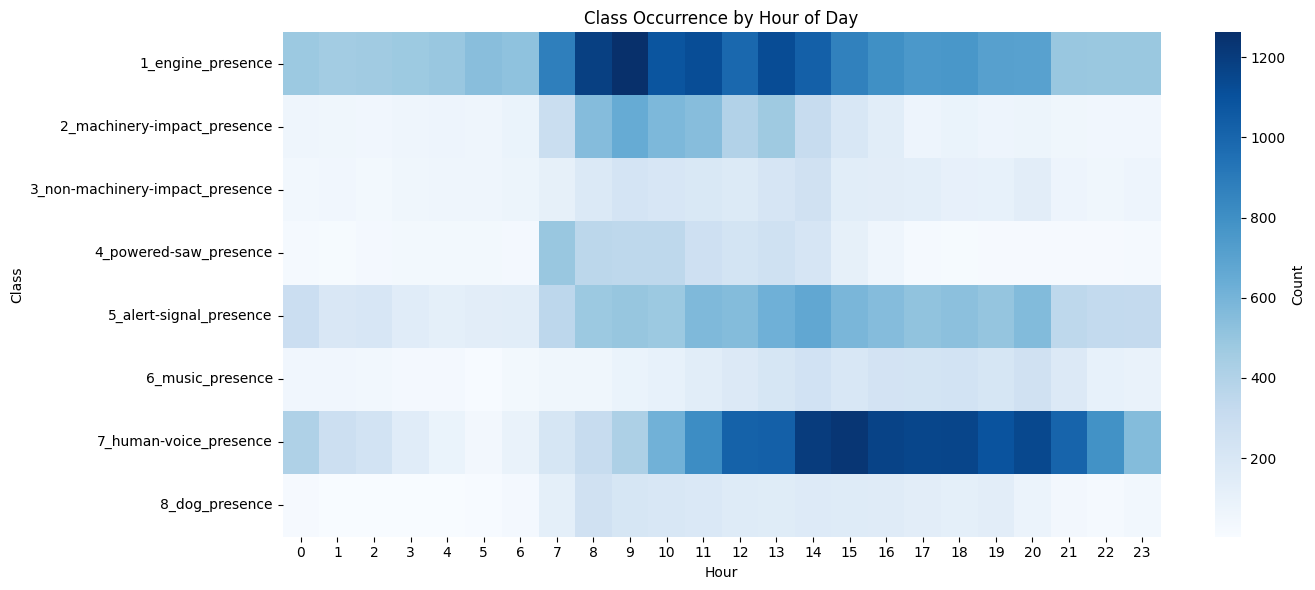

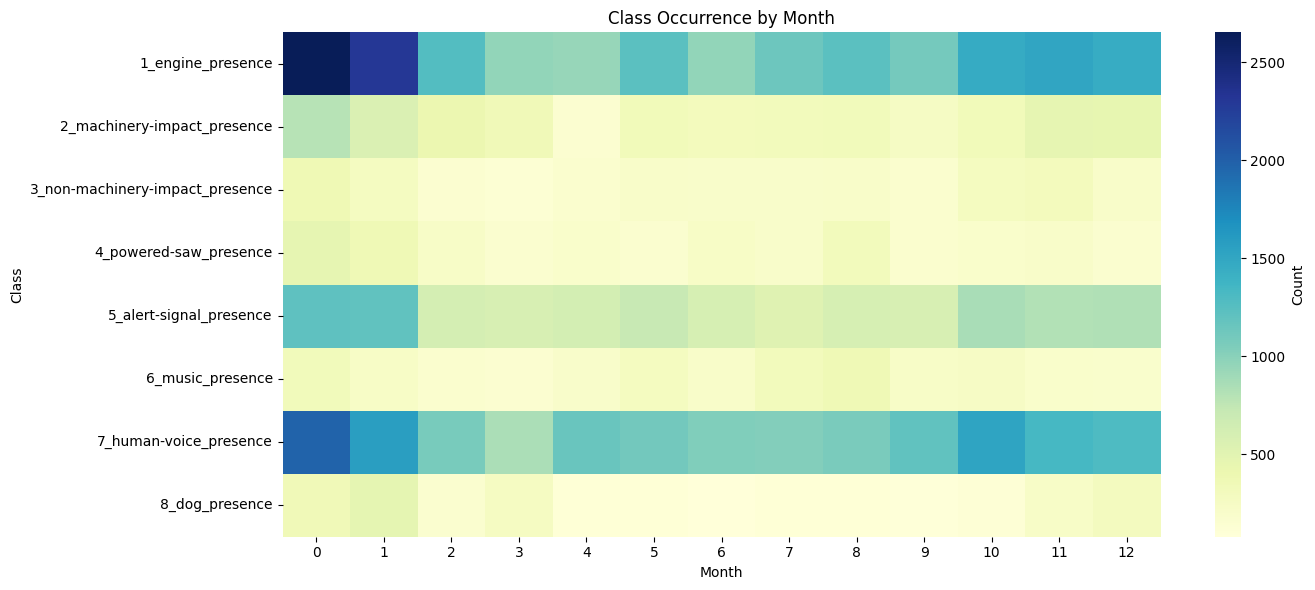

Epoch 1/10
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - auc_13: 0.4942 - binary_accuracy: 0.7952 - loss: -11.0664 - val_auc_13: 0.5083 - val_binary_accuracy: 0.8057 - val_loss: -209.6975
Epoch 2/10
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - auc_13: 0.4990 - binary_accuracy: 0.7890 - loss: -429.7079 - val_auc_13: 0.5132 - val_binary_accuracy: 0.6772 - val_loss: -1421.3479
Epoch 3/10
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - auc_13: 0.4990 - binary_accuracy: 0.7820 - loss: -1855.2296 - val_auc_13: 0.4986 - val_binary_accuracy: 0.7291 - val_loss: -3966.0464
Epoch 4/10
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - auc_13: 0.4986 - binary_accuracy: 0.7776 - loss: -4904.1465 - val_auc_13: 0.4989 - val_binary_accuracy: 0.8057 - val_loss: -7945.8960
Epoch 5/10
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - auc_13: 0.4985 - binary_accuracy: 0.7785 - loss: -9041.1768 - val_auc_13: 0.4988 - val_binary_accuracy: 0.8056 - val_loss: -13806.0850
Epoch 6/10
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 3

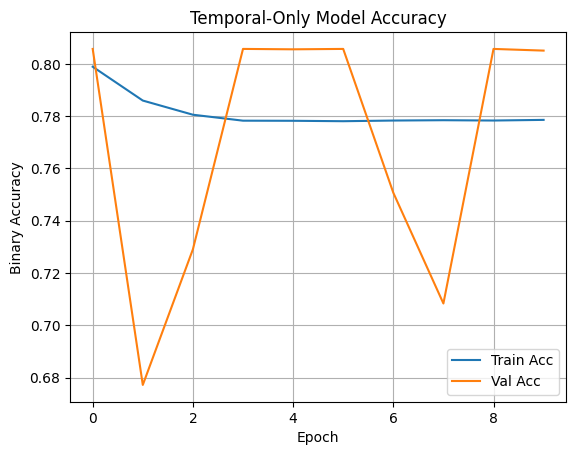

In [103]:
import pandas as pd
import os

data_home = "/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/sonyc-ust"
dataset_csv = os.path.join(data_home, "annotations.csv")
df = pd.read_csv(dataset_csv)

# Create ISO-format datetime string: "YYYY-Www-D H"
# - %G = ISO year, %V = ISO week number, %u = weekday (1=Mon to 7=Sun)
df['datetime_str'] = (
    df['year'].astype(str) + '-W' +
    df['week'].astype(str).str.zfill(2) + '-' +
    df['day'].astype(str) + ' ' +
    df['hour'].astype(str).str.zfill(2) + ':00:00'
)

# Parse to datetime
df['datetime'] = pd.to_datetime(df['datetime_str'], format='%G-W%V-%u %H:%M:%S', errors='coerce')

# Drop temporary string column
df.drop(columns='datetime_str', inplace=True)

# Extract standard components
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month.fillna(0).astype(int)
df['hour'] = df['hour'].fillna(0).astype(int)

# Use 8 aggregated label columns
label_cols = ['1_engine_presence', '2_machinery-impact_presence', '3_non-machinery-impact_presence',
              '4_powered-saw_presence', '5_alert-signal_presence', '6_music_presence',
              '7_human-voice_presence', '8_dog_presence']

# Melt for class-wise counts
long_df = df[['datetime', 'hour', 'day_of_week', 'week', 'month'] + label_cols].melt(
    id_vars=['datetime', 'hour', 'day_of_week', 'week', 'month'],
    var_name='class',
    value_name='present'
)
long_df = long_df[long_df['present'] == 1]

# Plot class counts by hour
hour_grouped = long_df.groupby(['hour', 'class']).size().unstack().fillna(0)
plt.figure(figsize=(14, 6))
sns.heatmap(hour_grouped.T, cmap="Blues", cbar_kws={'label': 'Count'})
plt.title("Class Occurrence by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

# Plot by month
month_grouped = long_df.groupby(['month', 'class']).size().unstack().fillna(0)
plt.figure(figsize=(14, 6))
sns.heatmap(month_grouped.T, cmap="YlGnBu", cbar_kws={'label': 'Count'})
plt.title("Class Occurrence by Month")
plt.xlabel("Month")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Normalize and one-hot temporal features
hour_norm = df['hour'] / 23.0
week_norm = df['week'] / 52.0
day_onehot = pd.get_dummies(df['day'], prefix='day')
month_onehot = pd.get_dummies(df['month'], prefix='month')

temporal_feats = np.concatenate([
    hour_norm.values[:, np.newaxis],
    week_norm.values[:, np.newaxis],
    day_onehot.values,
    month_onehot.values
], axis=1)

# Multilabel target
labels = df[label_cols].values.astype(np.float32)
X_train, X_val, y_train, y_val = train_test_split(temporal_feats, labels, test_size=0.2, random_state=42)

# Simple temporal-only model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(8, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', tf.keras.metrics.AUC(multi_label=True)]
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

# Plot accuracy
plt.plot(history.history['binary_accuracy'], label='Train Acc')
plt.plot(history.history['val_binary_accuracy'], label='Val Acc')
plt.title('Temporal-Only Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.legend()
plt.grid(True)
plt.show()

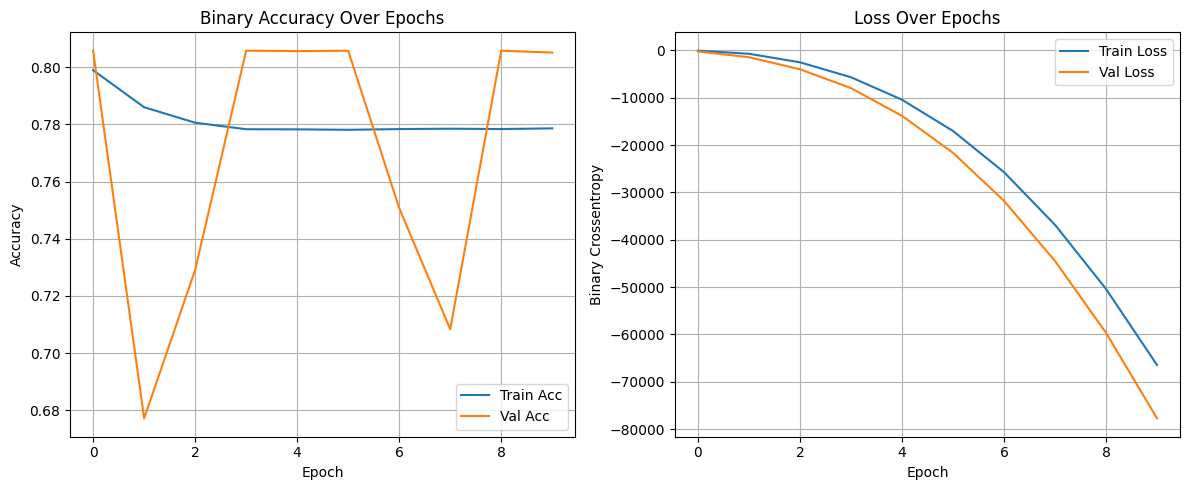

In [104]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['binary_accuracy'], label='Train Acc')
    plt.plot(history.history['val_binary_accuracy'], label='Val Acc')
    plt.title('Binary Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
import os
import numpy as np
np.complex = complex  # Temporary fix for librosa
import pandas as pd
import librosa
from glob import glob
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import load_model

from wrapper import SonycUST
from classification import build_cnn_model  # if needed, otherwise use load_model only

# === Paths ===
data_root = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/sonyc-ust'
csv_path = os.path.join(data_root, 'annotations.csv')
model_path = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/versions/noise-bliss-main_04_29_2025_2/best_model.keras'

# === Parameters ===
n_mels = 128
n_frames = 128
threshold = 0.05  # Try low threshold for testing

# === Classes ===
class_names = ['engine', 'machinery-impact', 'non-machinery-impact', 'powered-saw',
               'alert-signal', 'music', 'human-voice', 'dog']

# === Extract mel-spectrogram ===
def extract_mel_spectrogram(file_path, sr=16000):
    y, _ = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max, top_db=80) / 80.0
    mel_db = mel_db[:, :n_frames] if mel_db.shape[1] >= n_frames else np.pad(mel_db, ((0, 0), (0, n_frames - mel_db.shape[1])))
    return mel_db.T  # (128, 128)

# === Load data ===
dataset = SonycUST(data_root)
df = pd.read_csv(csv_path)

# === Resolve full paths ===
audio_files = glob(os.path.join(data_root, 'audio-*', '*.wav'))
filename_map = {os.path.basename(f): f for f in audio_files}
df['audio_path'] = df['audio_filename'].map(filename_map)
df = df[df['audio_path'].notna() & df['audio_path'].apply(os.path.exists)].reset_index(drop=True)

# === Construct datetime ===
df['week'] = df['week'].clip(1, 52)
df['hour'] = df['hour'].clip(0, 23)
df['datetime'] = pd.to_datetime(df['year'].astype(str) + df['week'].astype(str).str.zfill(2) + '1', format='%G%V%u')
df['datetime'] += pd.to_timedelta(df['hour'], unit='h')

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.dayofweek
df['week'] = df['datetime'].dt.isocalendar().week
df['month'] = df['datetime'].dt.month

# === Load model ===
model = load_model(model_path)

# === Prediction ===
prediction_records = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        mel = extract_mel_spectrogram(row['audio_path'])
        mel_input = np.expand_dims(mel, axis=(0, -1))  # (1, 128, 128, 1)
        preds = model.predict(mel_input, verbose=0)[0]

        prediction_records.append({
            'hour': row['hour'],
            'day': row['day'],
            'week': row['week'],
            'month': row['month'],
            **{cls: int(p >= threshold) for cls, p in zip(class_names, preds)}
        })
    except Exception as e:
        print(f"Error on {row['audio_path']}: {e}")
        continue

# === Convert to DataFrame ===
if not prediction_records:
    raise ValueError("No predictions recorded — check model input/output shapes and normalization.")

pred_df = pd.DataFrame(prediction_records)

# === Aggregate ===
summary_by_hour = pred_df.groupby('hour')[class_names].sum().astype(int)
summary_by_day = pred_df.groupby('day')[class_names].sum().astype(int)
summary_by_week = pred_df.groupby('week')[class_names].sum().astype(int)
summary_by_month = pred_df.groupby('month')[class_names].sum().astype(int)

summary_by_hour.to_csv("class_frequency_by_hour.csv")
summary_by_day.to_csv("class_frequency_by_day.csv")
summary_by_week.to_csv("class_frequency_by_week.csv")
summary_by_month.to_csv("class_frequency_by_month.csv")

print("✅ CSV summaries written: hour/day/week/month.")

 31%|███▏      | 19404/62022 [47:01<1:52:02,  6.34it/s]

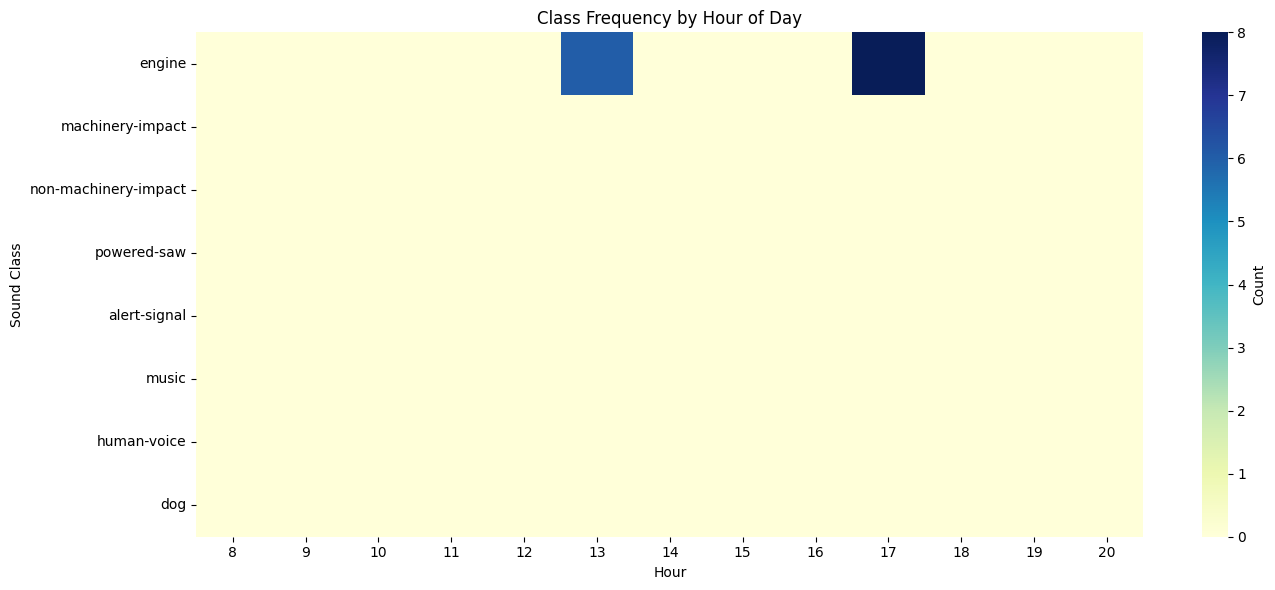

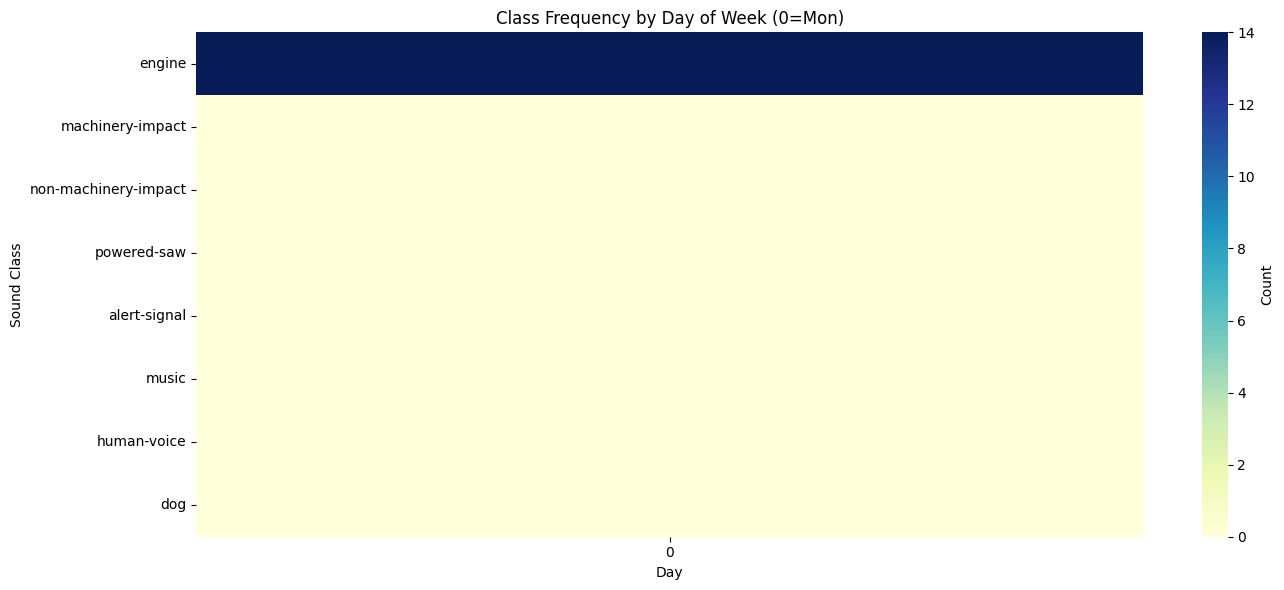

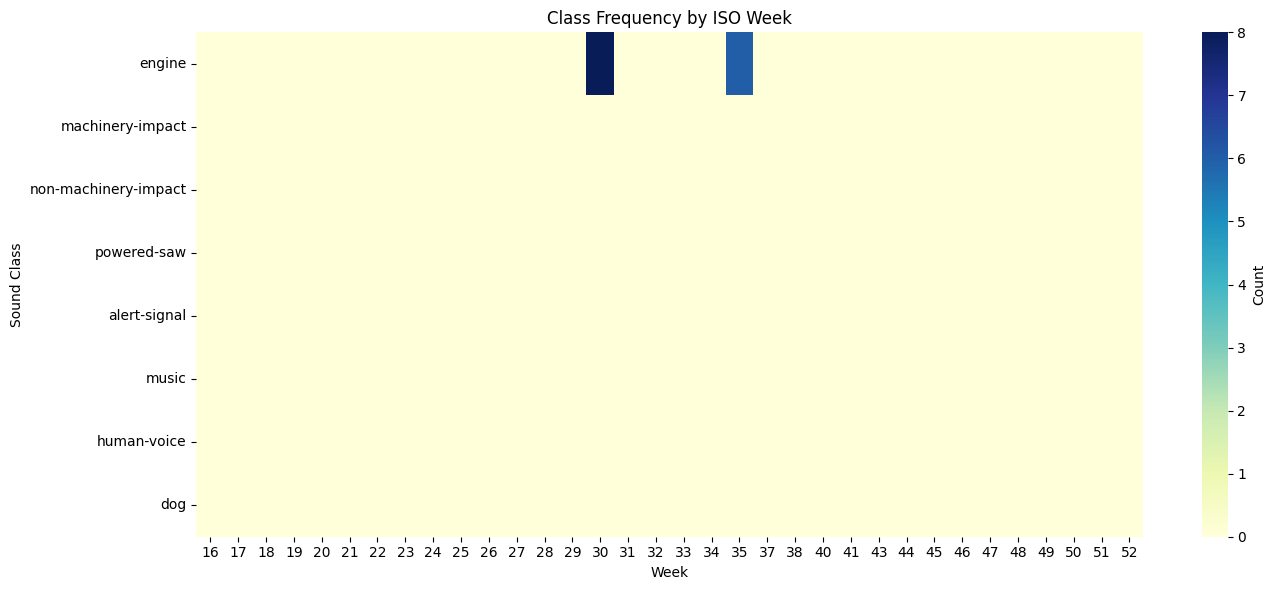

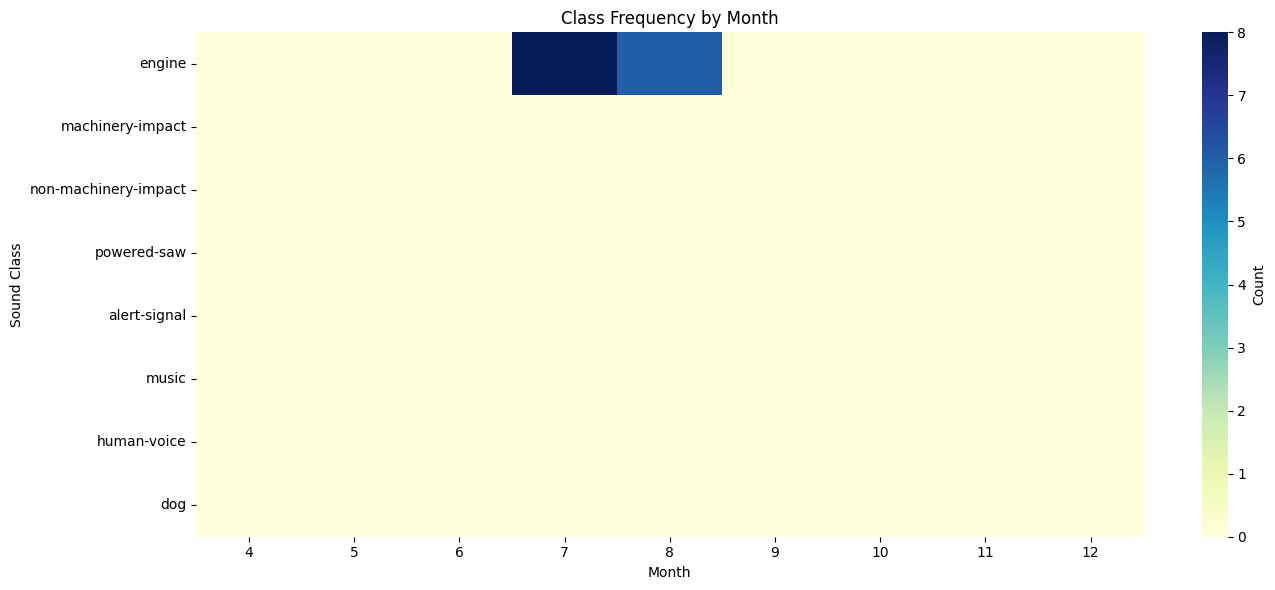

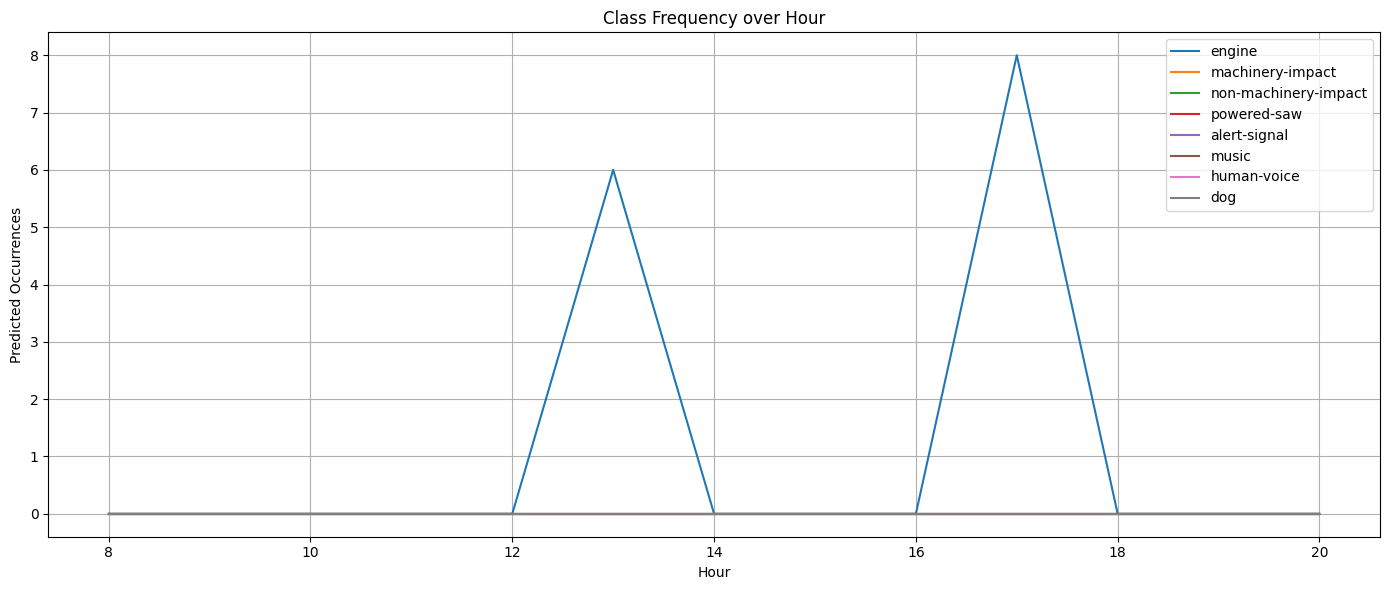

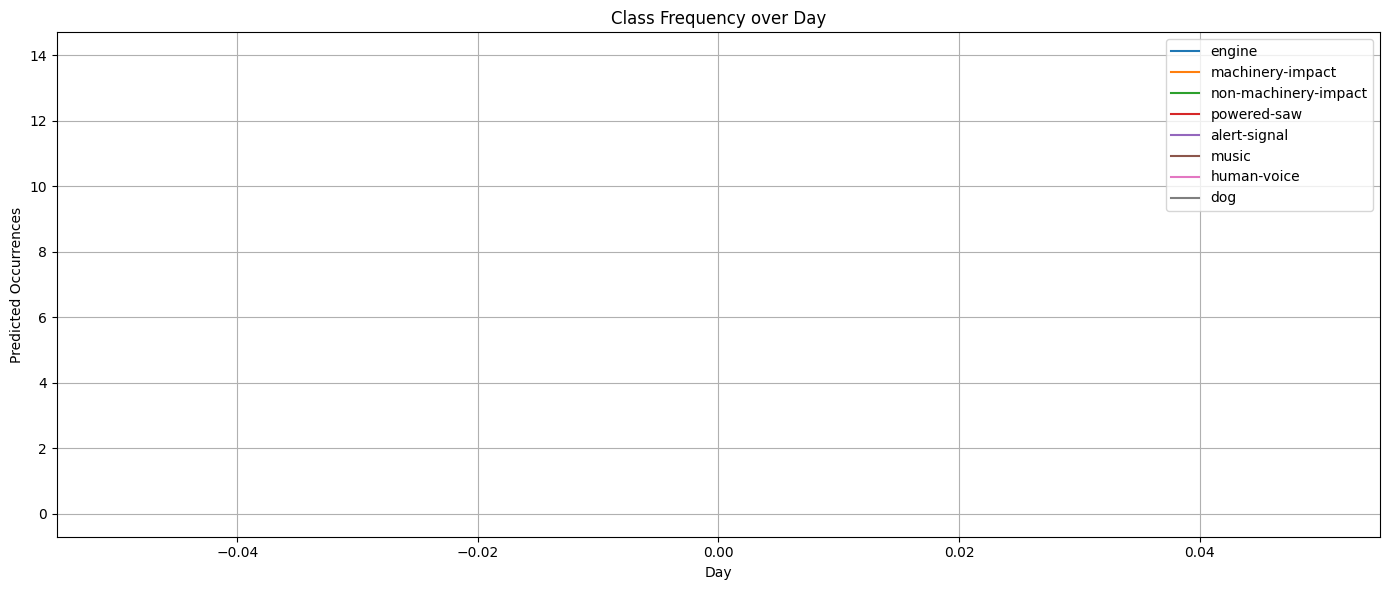

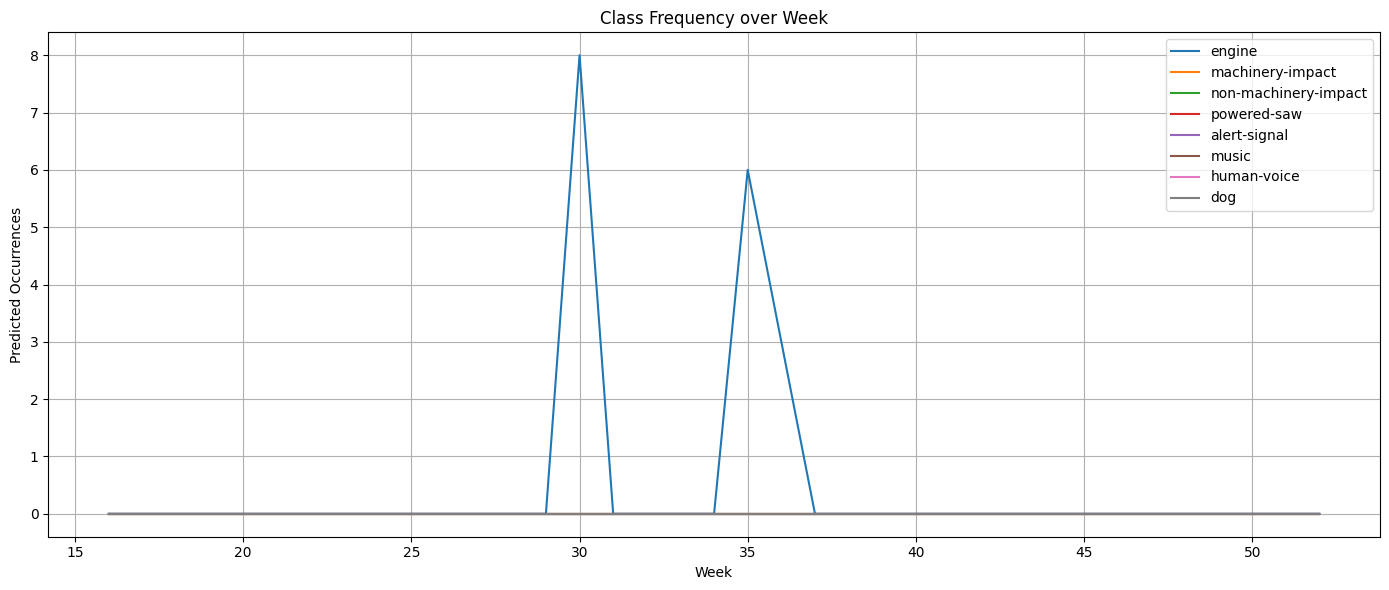

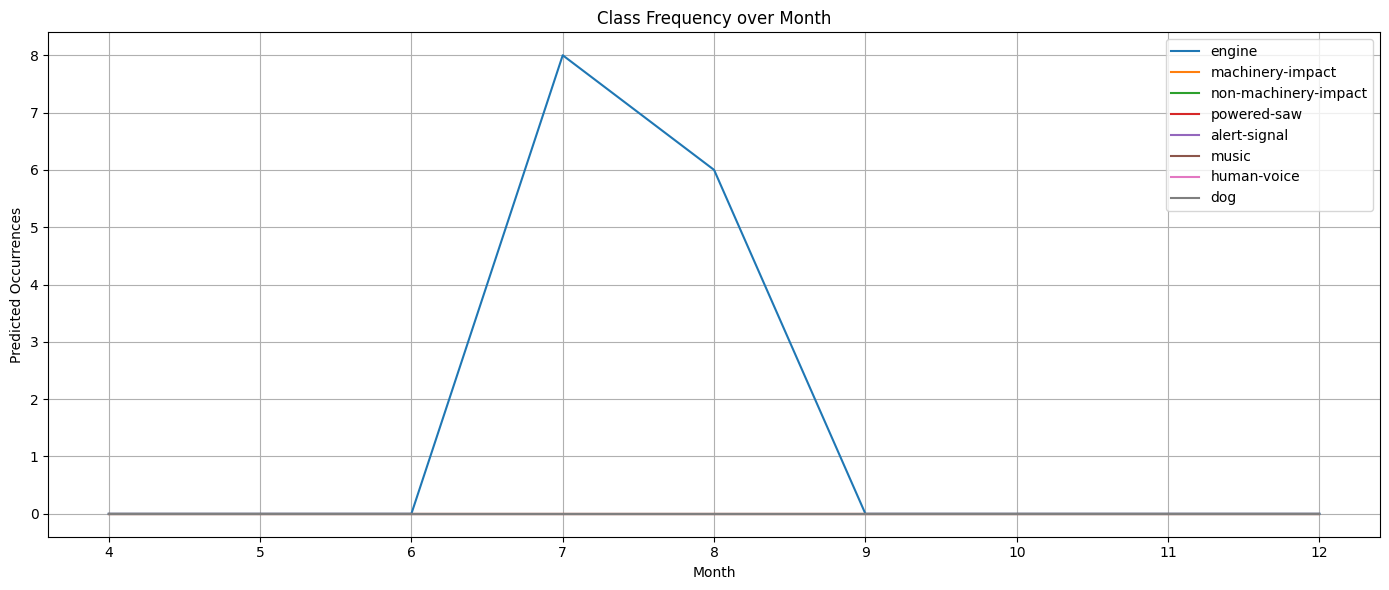

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# === Helper function ===
def plot_class_distribution(df, time_unit, title):
    plt.figure(figsize=(14, 6))
    sns.heatmap(df.T, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Count'})
    plt.title(f"Class Frequency by {title}")
    plt.xlabel(time_unit.capitalize())
    plt.ylabel("Sound Class")
    plt.tight_layout()
    plt.show()

# === Load summaries back (optional if still in memory) ===
plot_class_distribution(summary_by_hour, "hour", "Hour of Day")
plot_class_distribution(summary_by_day, "day", "Day of Week (0=Mon)")
plot_class_distribution(summary_by_week, "week", "ISO Week")
plot_class_distribution(summary_by_month, "month", "Month")

import matplotlib.pyplot as plt

def plot_line_distribution(summary_df, time_unit):
    plt.figure(figsize=(14, 6))
    for cls in summary_df.columns:
        plt.plot(summary_df.index, summary_df[cls], label=cls)
    plt.title(f"Class Frequency over {time_unit.capitalize()}")
    plt.xlabel(time_unit.capitalize())
    plt.ylabel("Predicted Occurrences")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Line plots ===
plot_line_distribution(summary_by_hour, "hour")
plot_line_distribution(summary_by_day, "day")
plot_line_distribution(summary_by_week, "week")
plot_line_distribution(summary_by_month, "month")

In [153]:
print("Example prediction:", pred)

Example prediction: [0.08609909 0.00144583 0.00084141 0.00659543 0.00047035 0.00037858
 0.00246775 0.05682333]
